# Analysis of LEK Dataset
This notebook performs a series of analyses to explore, preprocess, and model the data related to the target, "Benefit Knowledge" (Clove.Benefit.Score). The steps include feature selection, correlation analysis, multicollinearity check, RF model training, and permutation feature importance.

In [39]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, cohen_kappa_score
from sklearn.feature_selection import chi2
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor
import shap
from scipy.stats import chi2_contingency
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle
Seed = 1000
np.random.seed(Seed)
from docx import Document



In [40]:
# Sociodemographic dataset
data_socio = pd.read_csv(r'C:\Users\yazda\Desktop\AyeAye2024\Aye-Aye-Project\data\Benefit_sociodemographic_data.csv', delimiter=';')

# Binary dataset
data_binary = pd.read_csv(r'C:\Users\yazda\Desktop\AyeAye2024\Aye-Aye-Project\data\Benefit_Knowledge_data.csv', delimiter=';')
print(data_binary.columns)
print(data_socio.columns)
merged_data = pd.concat([data_binary, data_socio], axis=1)
merged_data.shape
merged_data = merged_data.loc[:, ~merged_data.columns.duplicated()]
print(data_socio.dtypes)
# print(merged_data.columns)

Index(['Clove.benefit.score', 'ID.nom', 'ID.vis.Aye', 'Other.lemurs',
       'Diet.Insects', 'Knowledge.signs', 'Knowledge.Abundance',
       'Activity.knowledge', 'Weight.knowledge', 'Lifestyle.knowledge',
       'Lemur.knowledge', 'Aye.aye.protected', 'encountered.binary'],
      dtype='object')
Index(['Clove.benefit.score', 'Region', 'Remoteness', 'village.size', 'School',
       'Forest.cover2017', 'Forest.cover1990', 'Gender', 'Agegroup',
       'edu.level', 'Ethnic.group', 'Migration.Experience', 'Farms.Cloves',
       'Farms.Paddy.Rice', 'Farms.Tavy.Rice', 'Extracts.Medical.plants'],
      dtype='object')
Clove.benefit.score         int64
Region                      int64
Remoteness                  int64
village.size                int64
School                      int64
Forest.cover2017           object
Forest.cover1990           object
Gender                      int64
Agegroup                   object
edu.level                  object
Ethnic.group                int64
Migrat

In [ ]:
def cramers_v(x, y):
    """
    Compute bias-corrected Cramér's V for two categorical variables.
    """
    contingency_table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    k, r = contingency_table.shape
    phi2 = chi2 / n  # Phi^2 statistic
    bias = (k - 1) * (r - 1) / n  # Small-sample bias
    corrected_phi2 = max(0, phi2 - bias)  # Ensure non-negative
    min_dim = min(k - 1, r - 1)  # Minimum dimension
    return np.sqrt(corrected_phi2 / min_dim)

results = {}
columns = merged_data.columns  
for col1 in columns:
    results[col1] = {}
    for col2 in columns:
        results[col1][col2] = cramers_v(merged_data[col1], merged_data[col2]) 

# Convert the results into a DataFrame
cramers_v_df = pd.DataFrame(results)

# Display the result
# print(cramers_v_df)

In [43]:
cramers_v_df

,Clove.benefit.score,ID.nom,ID.vis.Aye,Other.lemurs,Diet.Insects,Knowledge.signs,Knowledge.Abundance,Activity.knowledge,Weight.knowledge,Lifestyle.knowledge,...,Forest.cover1990,Gender,Agegroup,edu.level,Ethnic.group,Migration.Experience,Farms.Cloves,Farms.Paddy.Rice,Farms.Tavy.Rice,Extracts.Medical.plants
Clove.benefit.score,0.993544,0.132762,0.268918,0.280598,0.380126,0.120408,0.157525,0.289481,0.168475,0.130235,...,0.115012,0.332211,0.132177,0.102886,0.113039,0.069721,0.119957,0.077963,0.028257,0.171889
ID.nom,0.132762,0.992250,0.191741,0.180876,0.201333,0.163332,0.195973,0.133749,0.117943,0.219907,...,0.076849,0.211558,0.134599,0.000000,0.073931,0.000000,0.000000,0.187173,0.214221,0.032119
ID.vis.Aye,0.268918,0.191741,0.990384,0.224107,0.326394,0.161363,0.103409,0.160750,0.164327,0.112978,...,0.035884,0.241508,0.108775,0.161153,0.058288,0.000000,0.000000,0.000000,0.000000,0.000000
Other.lemurs,0.280598,0.180876,0.224107,0.992288,0.205300,0.000000,0.248058,0.213456,0.107151,0.140280,...,0.125799,0.255984,0.184156,0.000000,0.000000,0.000000,0.153112,0.088493,0.027631,0.179620
Diet.Insects,0.380126,0.201333,0.326394,0.205300,0.993289,0.287821,0.227657,0.316210,0.218312,0.242376,...,0.000000,0.266239,0.087872,0.000000,0.000000,0.000000,0.057797,0.055347,0.022577,0.130466
Knowledge.signs,0.120408,0.163332,0.161363,0.000000,0.287821,0.991138,0.153659,0.126739,0.145936,0.072929,...,0.073045,0.140742,0.013449,0.100512,0.000000,0.000000,0.000000,0.000000,0.032851,0.000000
Knowledge.Abundance,0.157525,0.195973,0.103409,0.248058,0.227657,0.153659,0.993609,0.165332,0.061081,0.162685,...,0.090856,0.148390,0.222058,0.086401,0.000000,0.000000,0.049783,0.078332,0.034678,0.048092
Activity.knowledge,0.289481,0.133749,0.160750,0.213456,0.316210,0.126739,0.165332,0.993437,0.172762,0.147516,...,0.060468,0.137356,0.152677,0.000000,0.000000,0.052508,0.100307,0.075815,0.000000,0.216822
Weight.knowledge,0.168475,0.117943,0.164327,0.107151,0.218312,0.145936,0.061081,0.172762,0.992211,0.000000,...,0.082563,0.144940,0.115792,0.115937,0.039242,0.000000,0.036212,0.000000,0.062645,0.000000
Lifestyle.knowledge,0.130235,0.219907,0.112978,0.140280,0.242376,0.072929,0.162685,0.147516,0.000000,0.993524,...,0.000000,0.096398,0.000000,0.000000,0.000000,0.074316,0.000000,0.074335,0.000000,0.122309


### Preprocessing - Encoding

In [44]:
# Pre-processing Function 
def preprocess_data_with_one_hot_encoding(data):
    data.drop(['Forest.cover2017', 'Forest.cover1990'], axis=1, inplace=True)
    # Handle missing values and encode educational level
    data['edu.level'] = data['edu.level'].fillna('NoEducation')
    data['edu.level'] = data['edu.level'].replace({'NoEducation': '1', 'Primary': '2', 'Secondary': '3', 'High': '4'})

    # Exclude the target column from one-hot encoding
    if 'Clove.benefit.score' in data.columns:
        target = data['Clove.benefit.score']
        data.drop('Clove.benefit.score', axis=1, inplace=True)
    
    # One-hot encoding for categorical variables
    data = pd.get_dummies(data, columns=['Gender', 'Region', 'Agegroup', 'edu.level'], 
                          drop_first=True, 
                          dtype=int,
                          prefix_sep='_')
    data = data.rename(columns={'Gender_1': 'Male'})
    data = data.rename(columns={'ID.vis.Aye': 'ID_photo'})
    data = data.rename(columns={'ID.nom': 'ID_name'})
    data = data.rename(columns={'Other.lemurs': 'ID_other'})
    data = data.rename(columns={'encountered.binary': 'Encounter'})     
    data = data.rename(columns={'Diet.Insects': 'Knows_insect'})
    data = data.rename(columns={'Knowledge.signs': 'Knows_signs'})
    data = data.rename(columns={'Weight.knowledge': 'Knows_size'})
    data = data.rename(columns={'Lifestyle.knowledge': 'Knows_lifestyle'})
    data = data.rename(columns={'Activity.knowledge': 'Knows_activity'})
    data = data.rename(columns={'Aye.aye.protected': 'Knows_protected'})
    data = data.rename(columns={'Lemur.knowledge': 'Knows_lemur'})
    data = data.rename(columns={'Knowledge.Abundance': 'Knows_abundance'})

    return data, target

# Preprocess the merged dataset
X_merged_encoded, y_merged_encoded = preprocess_data_with_one_hot_encoding(merged_data)
print(X_merged_encoded.columns)


Index(['ID_name', 'ID_photo', 'ID_other', 'Knows_insect', 'Knows_signs',
       'Knows_abundance', 'Knows_activity', 'Knows_size', 'Knows_lifestyle',
       'Knows_lemur', 'Knows_protected', 'Encounter', 'Remoteness',
       'village.size', 'School', 'Ethnic.group', 'Migration.Experience',
       'Farms.Cloves', 'Farms.Paddy.Rice', 'Farms.Tavy.Rice',
       'Extracts.Medical.plants', 'Male', 'Region_1', 'Region_2', 'Region_3',
       'Agegroup_21-30', 'Agegroup_31-40', 'Agegroup_41-50', 'Agegroup_51-60',
       'Agegroup_61-70', 'Agegroup_>70', 'edu.level_2', 'edu.level_3',
       'edu.level_4'],
      dtype='object')


### Training Model - Feature Importance - Incremental Feature Addition - Random Forest 

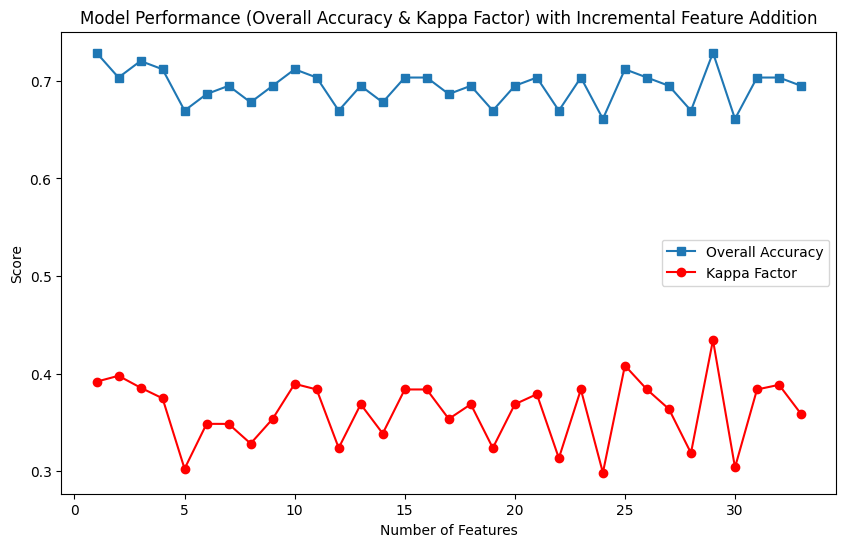

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_merged_encoded, y_merged_encoded, test_size=0.3, random_state=Seed)
rf = RandomForestClassifier(min_samples_leaf=4, min_samples_split=10, n_estimators=100, random_state=Seed)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
sorted_indices = np.argsort(importances)[::-1]
sorted_features = X_train.columns[sorted_indices]

X_train_sorted = X_train.iloc[:, sorted_indices]
X_test_sorted = X_test.iloc[:, sorted_indices]

results = []

for i in range(2, X_train_sorted.shape[1] + 1):
    # Select the top i features
    X_train_subset = X_train_sorted.iloc[:, :i]
    X_test_subset = X_test_sorted.iloc[:, :i]
    rf_subset = RandomForestClassifier(random_state=Seed)
    rf_subset.fit(X_train_subset, y_train)

    y_pred = rf_subset.predict(X_test_subset)

    accuracy = accuracy_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    
    results.append({
        "Iteration": i - 1,
        "Feature": sorted_features[i - 1],
        "Accuracy": accuracy,
        "Kappa": kappa
    })

results_df = pd.DataFrame(results)

results_df['Accuracy_Slope'] = results_df['Accuracy'].diff()
results_df['Kappa_Slope'] = results_df['Kappa'].diff()

# Identify significant changes based on slope thresholds
accuracy_threshold = 0.02
kappa_threshold = 0.02

significant_changes = results_df[(results_df['Accuracy_Slope'].abs() > accuracy_threshold) |
                                 (results_df['Kappa_Slope'].abs() > kappa_threshold)]

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(results_df['Iteration'], results_df['Accuracy'], marker='s', label='Overall Accuracy')
plt.plot(results_df['Iteration'], results_df['Kappa'], marker='o', label='Kappa Factor', color='red')
plt.xlabel('Number of Features')
plt.ylabel('Score')
plt.title('Model Performance (Overall Accuracy & Kappa Factor) with Incremental Feature Addition')
plt.legend()
plt.show()


In [46]:
# Data Preprocessing for Binary-Only Dataset (No Categorical Encoding)
X_binary = data_binary.drop('Clove.benefit.score', axis=1)
y_binary = data_binary['Clove.benefit.score']

# Train-test split for the binary dataset
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(X_binary, y_binary, test_size=0.3, random_state=Seed)


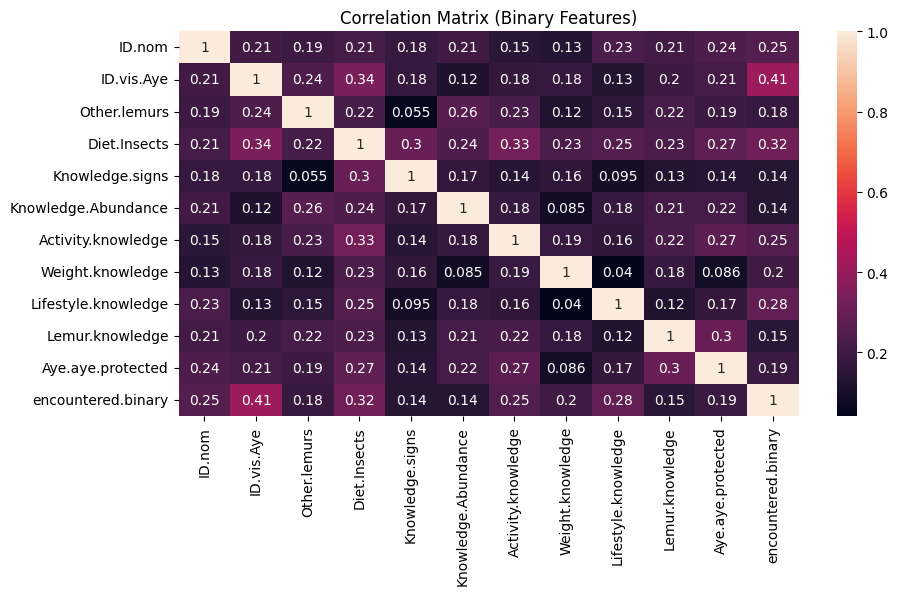

In [47]:
plt.figure(figsize=(10, 5))
sns.heatmap(X_binary.corr('pearson'), annot=True)
plt.title("Correlation Matrix (Binary Features)")
plt.show()

### Choosing Micro-Averaged Jaccard Score for Feature Importance - Binary Features
To assess feature importance in this analysis, we use the **micro-averaged Jaccard score**. This metric is more suitable because it considers each individual instance's performance, providing a more granular view of how features contribute to the model's predictions. The micro-averaged approach is particularly useful when we aim to prioritize the model's ability to handle each instance equally, without being biased towards any particular class. As our goal is to uncover which features have the most impact across all instances, the micro-averaged Jaccard score will give a balanced measure of feature importance, aligning with our analysis objectives.


                Feature  Jaccard_Score
3          Diet.Insects       0.540275
1            ID.vis.Aye       0.476460
6    Activity.knowledge       0.465421
11   encountered.binary       0.441176
7      Weight.knowledge       0.435897
2          Other.lemurs       0.430657
9       Lemur.knowledge       0.422868
4       Knowledge.signs       0.417722
5   Knowledge.Abundance       0.415162
10    Aye.aye.protected       0.415162
8   Lifestyle.knowledge       0.407540
0                ID.nom       0.368237




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



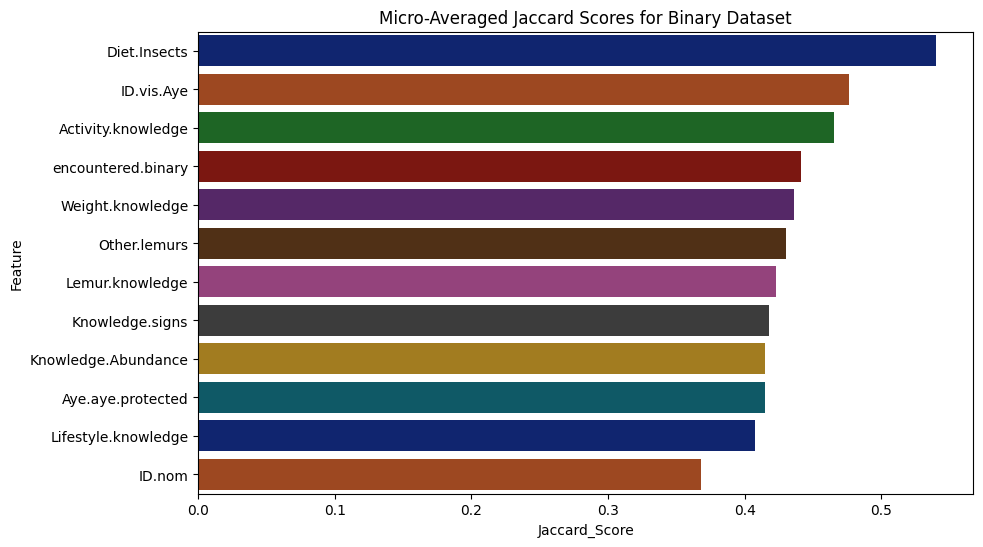

In [ ]:
# Micro-Averaged Jaccard Correlation for Binary-Only Dataset
from sklearn.metrics import jaccard_score

# Jaccard scores using micro-averaging
jaccard_scores_binary_micro = {}
for column in X_binary.columns:
    try:
        score = jaccard_score(y_binary, X_binary[column], average='micro')
        jaccard_scores_binary_micro[column] = score
    except ValueError:
        continue

jaccard_df_binary_micro = pd.DataFrame(list(jaccard_scores_binary_micro.items()), columns=['Feature', 'Jaccard_Score']).sort_values(by='Jaccard_Score', ascending=False)
print(jaccard_df_binary_micro)
plt.figure(figsize=(10, 6))
sns.barplot(x='Jaccard_Score', y='Feature', data=jaccard_df_binary_micro, palette='dark')
plt.title('Micro-Averaged Jaccard Scores for Binary Dataset')
plt.show()


In [49]:
vif_raw = pd.DataFrame()
vif_raw['Feature'] = X_merged_encoded.columns
vif_raw['VIF'] = [variance_inflation_factor(X_merged_encoded.values, i) for i in range(X_merged_encoded.shape[1])]
print(vif_raw)
print("--------------------------------------------------")

vif_threshold = 5

features_to_drop = vif_raw[vif_raw['VIF'] > vif_threshold]['Feature']

print("Features with High VIF:\n",features_to_drop)
print("--------------------------------------------------")
X_raw_reduced = X_merged_encoded.drop(features_to_drop, axis=1)

vif_raw_reduced = pd.DataFrame()
vif_raw_reduced['Feature'] = X_raw_reduced.columns
vif_raw_reduced['VIF'] = [variance_inflation_factor(X_raw_reduced.values, i) for i in range(X_raw_reduced.shape[1])]
print(vif_raw_reduced)
print(vif_raw_reduced.shape)


                    Feature        VIF
0                   ID_name   5.844474
1                  ID_photo   1.773775
2                  ID_other   5.206614
3              Knows_insect   2.426274
4               Knows_signs   1.563534
5           Knows_abundance   2.542728
6            Knows_activity   3.479936
7                Knows_size   1.660676
8           Knows_lifestyle   2.254995
9               Knows_lemur   2.897691
10          Knows_protected   5.083936
11                Encounter   1.870301
12               Remoteness  16.275820
13             village.size  16.226071
14                   School   5.664353
15             Ethnic.group   7.333550
16     Migration.Experience   1.602056
17             Farms.Cloves  16.523934
18         Farms.Paddy.Rice   3.817516
19          Farms.Tavy.Rice   4.394834
20  Extracts.Medical.plants   2.949715
21                     Male   3.835521
22                 Region_1  16.498668
23                 Region_2  15.531414
24                 Region

In [50]:
# Step 1: Compute Chi-Square with Yates' Correction and Clip the First 21 Features with p < 0.05
chi2_scores = []
p_values = []

for feature in X_merged_encoded.columns:
    contingency_table = pd.crosstab(X_merged_encoded[feature], y_merged_encoded)
    chi2, p, _, _ = chi2_contingency(contingency_table, correction=True)
    chi2_scores.append(chi2)
    p_values.append(p)

chi2_results = pd.DataFrame({
    'Feature': X_merged_encoded.columns,
    'Chi2 Score': chi2_scores,
    'p-value': p_values
}).sort_values(by='p-value', ascending=True)

# Select features with p-value < 0.05
top_features = chi2_results[chi2_results['p-value'] < 0.05].head(21)['Feature']
X_top_features = X_merged_encoded[top_features]

# Step 2: Compute VIF for Selected Features and Remove High VIF Features
vif_df = pd.DataFrame()
vif_df['Feature'] = X_top_features.columns
vif_df['VIF'] = [variance_inflation_factor(X_top_features.values, i) for i in range(X_top_features.shape[1])]

# Filter features with VIF below the threshold (10)
vif_threshold = 5
low_vif_features = vif_df[vif_df['VIF'] <= vif_threshold]['Feature']
X_reduced = X_top_features[low_vif_features]

# Step 3: Results
result = {
    'Chi2 Results (Top 21 Features)': chi2_results.head(21),
    'VIF Before Reduction': vif_df,
    'VIF After Reduction': pd.DataFrame({
        'Feature': low_vif_features,
        'VIF': [variance_inflation_factor(X_reduced.values, i) for i in range(X_reduced.shape[1])]
    })
}

print(result)

{'Chi2 Results (Top 21 Features)':                     Feature  Chi2 Score       p-value
3              Knows_insect   57.642360  3.143817e-14
21                     Male   44.262653  2.871423e-11
6            Knows_activity   33.849407  5.954723e-09
2                  ID_other   31.864301  1.653279e-08
1                  ID_photo   29.348177  6.047339e-08
10          Knows_protected   25.749238  3.887804e-07
9               Knows_lemur   14.943881  1.107567e-04
22                 Region_1   14.342780  1.523629e-04
11                Encounter   13.867661  1.961447e-04
20  Extracts.Medical.plants   12.581959  3.894883e-04
7                Knows_size   12.126518  4.970985e-04
5           Knows_abundance   10.727133  1.055759e-03
0                   ID_name    7.909265  4.918225e-03
8           Knows_lifestyle    7.648755  5.681152e-03
13             village.size   14.538808  5.759863e-03
28           Agegroup_51-60    7.520150  6.101260e-03
4               Knows_signs    6.683249  9.7323

### Chi-square After VIF

In [ ]:
chi2_scores = []
p_values = []

for feature in X_merged_encoded.columns:
    contingency_table = pd.crosstab(X_merged_encoded[feature], y_merged_encoded)
    chi2, p, _, _ = chi2_contingency(contingency_table, correction=True)
    chi2_scores.append(chi2)
    p_values.append(p)

# Create a DataFrame to store Chi-Square results
chi2_results = pd.DataFrame({
    'Feature': X_merged_encoded.columns,
    'Chi2 Score': chi2_scores,
    'p-value': p_values
}).sort_values(by='p-value', ascending=True)

top_features = chi2_results[chi2_results['p-value'] < 0.05].head(30)['Feature']
X_top_features = X_merged_encoded[top_features]

# Step 2: Compute VIF and Remove High VIF Features
vif_df = pd.DataFrame()
vif_df['Feature'] = X_top_features.columns
vif_df['VIF'] = [variance_inflation_factor(X_top_features.values, i) for i in range(X_top_features.shape[1])]
print(vif_df['Feature'])
# Remove features with VIF > 5
vif_threshold = 5
low_vif_features = vif_df[vif_df['VIF'] <= vif_threshold]['Feature']
X_reduced = X_top_features[low_vif_features]

# Step 3: Split the Data into Train and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y_merged_encoded, test_size=0.3, random_state=Seed)

# Print the results
print("Final Features for Training:")
print(X_reduced.columns)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

0                Knows_insect
1                        Male
2              Knows_activity
3                    ID_other
4                    ID_photo
5             Knows_protected
6                 Knows_lemur
7                    Region_1
8                   Encounter
9     Extracts.Medical.plants
10                 Knows_size
11            Knows_abundance
12                    ID_name
13            Knows_lifestyle
14               village.size
15             Agegroup_51-60
16                Knows_signs
17               Farms.Cloves
18                     School
19                   Region_2
20               Ethnic.group
Name: Feature, dtype: object
Final Features for Training:
Index(['Knows_insect', 'Male', 'Knows_activity', 'ID_other', 'ID_photo',
       'Knows_protected', 'Knows_lemur', 'Region_1', 'Encounter',
       'Extracts.Medical.plants', 'Knows_size', 'Knows_abundance', 'ID_name',
       'Knows_lifestyle', 'Agegroup_51-60', 'Knows_signs', 'School',
       'Region_2'],
      

### Chi-square Test with Merged Dataset (Binary + Categorical) - Top 11 Features

In [ ]:
# plt.figure(figsize=(10, 6))
# sns.barplot(x='Chi2 Score', y='Feature', data=chi2_df_merged.head(11), palette='viridis')
# plt.title('Top 11 Features Based on Chi-Square Test (Merged Dataset)')
# plt.show()
# # print(top_11_features)
# # Select the top 11 features
# top_11_features = chi2_df_merged.head(11)['Feature'].tolist()

# # Extract the selected features for X
# X_top_11 = X_raw_reduced[top_11_features]

# # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X_top_11, y_merged_encoded, test_size=0.2, random_state=Seed)

# # Display the shapes of the resulting datasets
# print(f'X_train shape: {X_train.shape}')
# print(f'X_test shape: {X_test.shape}')
# print(f'y_train shape: {y_train.shape}')
# print(f'y_test shape: {y_test.shape}')

###  Multicollinearity Check using VIF (Merged Dataset) after Choosing top 21 Features from Chi-square

In [ ]:
# vif_data_merged = pd.DataFrame()
# vif_data_merged['Feature'] = X_top_11.columns
# vif_data_merged['VIF'] = [variance_inflation_factor(X_top_11.values, i) for i in range(X_top_11.shape[1])]

# vif_threshold = 5

# features_to_drop = vif_data_merged[vif_data_merged['VIF'] > vif_threshold]['Feature']
# print("Features with High VIF:",features_to_drop)
# print("--------------------------------------------------")
# X_merged_reduced = X_top_11.drop(features_to_drop, axis=1)

# vif_data_merged_reduced = pd.DataFrame()
# vif_data_merged_reduced['Feature'] = X_merged_reduced.columns
# vif_data_merged_reduced['VIF'] = [variance_inflation_factor(X_merged_reduced.values, i) for i in range(X_merged_reduced.shape[1])]
# print(vif_data_merged_reduced)
# print(vif_data_merged_reduced.shape)


### Model Training and Evaluation
- Train Logistic Regression, Random Forest, and XGBoost models.
- Perform hyperparameter tuning using GridSearchCV for XGBoost.
- Evaluate models using accuracy, precision, recall, and F1-score.

In [52]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_performances = {}

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)
model_performances['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_logreg),
    'Precision': precision_score(y_test, y_pred_logreg),
    'Recall': recall_score(y_test, y_pred_logreg),
    'F1-Score': f1_score(y_test, y_pred_logreg)
}
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_logreg))

rf = RandomForestClassifier(min_samples_leaf=4, min_samples_split=10,
                       n_estimators=200, random_state=Seed)

rf.fit(X_train, y_train) 
y_pred_rf = rf.predict(X_test)
model_performances['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf)
}
print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=Seed)
xgb.fit(X_train, y_train)  
y_pred_xgb = xgb.predict(X_test)
model_performances['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb)
}
print("XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))

print("\nModel Performance Summary:")
for model, scores in model_performances.items():
    print(f"{model}:")
    for metric, score in scores.items():
        print(f"  {metric}: {score:.4f}")

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.77      0.74      0.75        72
           1       0.61      0.65      0.63        46

    accuracy                           0.70       118
   macro avg       0.69      0.69      0.69       118
weighted avg       0.71      0.70      0.70       118

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        72
           1       0.72      0.72      0.72        46

    accuracy                           0.78       118
   macro avg       0.77      0.77      0.77       118
weighted avg       0.78      0.78      0.78       118

XGBoost Performance:
              precision    recall  f1-score   support

           0       0.71      0.62      0.67        72
           1       0.51      0.61      0.55        46

    accuracy                           0.62       118
   macro avg       0.61      0.62      0.61    

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.77      0.74      0.75        72
           1       0.61      0.65      0.63        46

    accuracy                           0.70       118
   macro avg       0.69      0.69      0.69       118
weighted avg       0.71      0.70      0.70       118

AUC: 0.7760
Random Forest Performance:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        72
           1       0.72      0.72      0.72        46

    accuracy                           0.78       118
   macro avg       0.77      0.77      0.77       118
weighted avg       0.78      0.78      0.78       118

AUC: 0.7926
XGBoost Performance:
              precision    recall  f1-score   support

           0       0.71      0.62      0.67        72
           1       0.51      0.61      0.55        46

    accuracy                           0.62       118
   macro avg       0.61



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



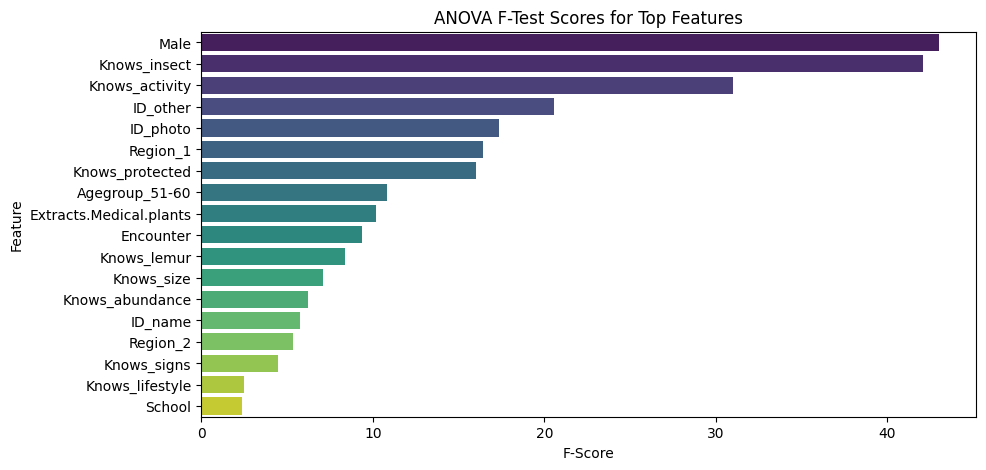



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



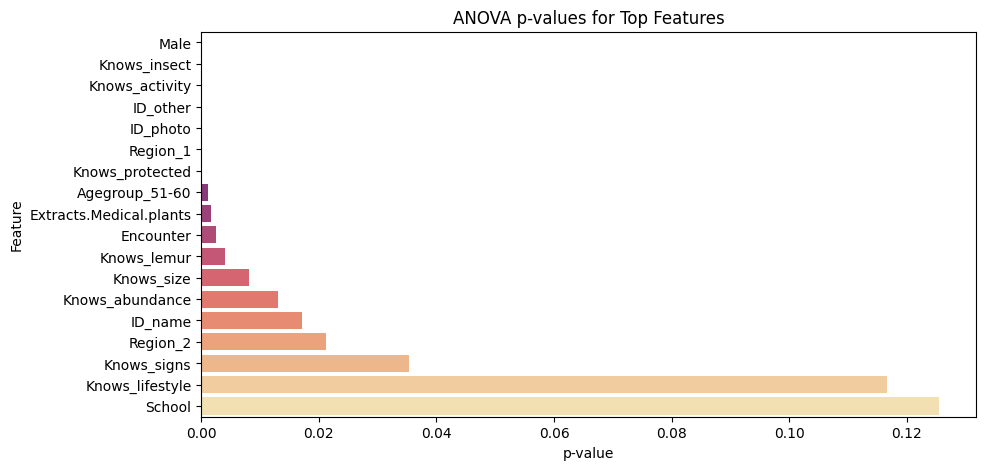

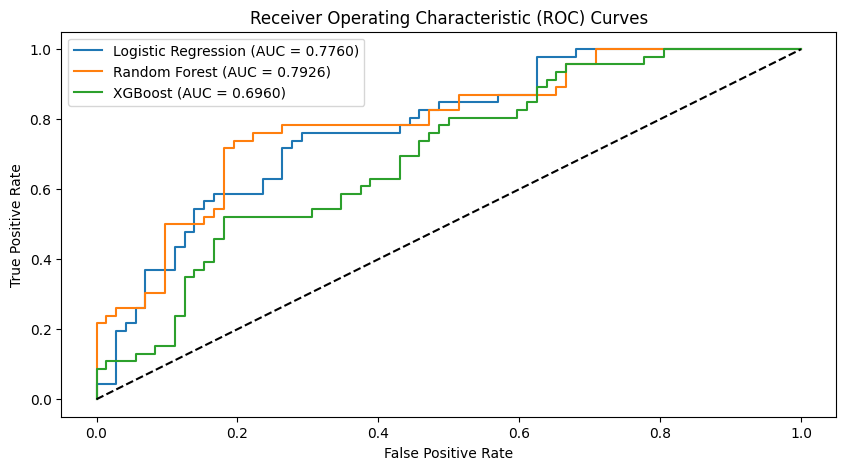


Model Performance Summary:
Logistic Regression:
  Accuracy: 0.7034
  Precision: 0.6122
  Recall: 0.6522
  F1-Score: 0.6316
  AUC: 0.7760
Random Forest:
  Accuracy: 0.7797
  Precision: 0.7174
  Recall: 0.7174
  F1-Score: 0.7174
  AUC: 0.7926
XGBoost:
  Accuracy: 0.6186
  Precision: 0.5091
  Recall: 0.6087
  F1-Score: 0.5545
  AUC: 0.6960


In [53]:
# Model Performance 
model_performances = {}

# 1. Logistic Regression Performance
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]  # For AUC

model_performances['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_logreg),
    'Precision': precision_score(y_test, y_pred_logreg),
    'Recall': recall_score(y_test, y_pred_logreg),
    'F1-Score': f1_score(y_test, y_pred_logreg),
    'AUC': roc_auc_score(y_test, y_pred_proba_logreg)
}

print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_logreg))
print(f"AUC: {model_performances['Logistic Regression']['AUC']:.4f}")

# 2. Random Forest Performance
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]  # For AUC

model_performances['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'AUC': roc_auc_score(y_test, y_pred_proba_rf)
}

print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))
print(f"AUC: {model_performances['Random Forest']['AUC']:.4f}")

# 3. XGBoost Performance
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]  # For AUC

model_performances['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb),
    'AUC': roc_auc_score(y_test, y_pred_proba_xgb)
}

print("XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC: {model_performances['XGBoost']['AUC']:.4f}")

# 4. Feature Importance - ANOVA F-Test
f_scores, p_values = f_classif(X_train, y_train)
anova_df = pd.DataFrame({'Feature': X_train.columns, 'F-Score': f_scores, 'p-value': p_values})
anova_df = anova_df.sort_values(by='F-Score', ascending=False)
print("\nANOVA F-Test for Features:")
print(anova_df)
anova_df = anova_df.sort_values(by='F-Score', ascending=False)

# Plotting the ANOVA F-Scores
plt.figure(figsize=(10, 5))
sns.barplot(x='F-Score', y='Feature', data=anova_df, palette='viridis')
plt.title('ANOVA F-Test Scores for Top Features')
plt.xlabel('F-Score')
plt.ylabel('Feature')
plt.show()

# Plotting the ANOVA p-values
plt.figure(figsize=(10, 5))
sns.barplot(x='p-value', y='Feature', data=anova_df, palette='magma')
plt.title('ANOVA p-values for Top Features')
plt.xlabel('p-value')
plt.ylabel('Feature')
plt.show()

# 5. Plotting ROC Curves for Each Model
plt.figure(figsize=(10, 5))

# ROC for Logistic Regression
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_proba_logreg)
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {model_performances["Logistic Regression"]["AUC"]:.4f})')

# ROC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {model_performances["Random Forest"]["AUC"]:.4f})')

# ROC for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {model_performances["XGBoost"]["AUC"]:.4f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend()
plt.show()

# 6. Summary of Model Performance
print("\nModel Performance Summary:")
for model, scores in model_performances.items():
    print(f"{model}:")
    for metric, score in scores.items():
        print(f"  {metric}: {score:.4f}")


In [ ]:
data = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.7034, 0.7797, 0.6186],
    "Precision": [0.6122, 0.7174, 0.5091],
    "Recall": [0.6522, 0.7174, 0.6087],
    "F1-Score": [0.6316, 0.7174, 0.5545],
    "AUC": [0.7760, 0.7926, 0.6960],
}

# Create a DataFrame
performance_summary = pd.DataFrame(data)
doc = Document()
doc.add_heading('Model Performance Summary', level=1)

# Add a table to the Word document
table = doc.add_table(rows=1, cols=len(performance_summary.columns))
table.style = 'Table Grid'

# Add column headers
for i, column_name in enumerate(performance_summary.columns):
    table.cell(0, i).text = column_name

# Add data rows
for _, row in performance_summary.iterrows():
    row_cells = table.add_row().cells
    for i, value in enumerate(row):
        row_cells[i].text = str(value)

# Save the document
doc.save('ModelPerformance.docx')


The figure presents the Receiver Operating Characteristic (ROC) curves for three classification models: Logistic Regression, Random Forest, and XGBoost. Among the models, Random Forest demonstrates the highest discriminative performance with an AUC of 0.7899, closely followed by Logistic Regression (AUC = 0.7880). XGBoost, in comparison, achieves a lower AUC of 0.6905, indicating relatively weaker classification performance. The ROC curves highlight the ability of each model to balance sensitivity and specificity, with Random Forest and Logistic Regression showing comparable and superior performance in this evaluation.

### Permutation Importance of Merged Dataset



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



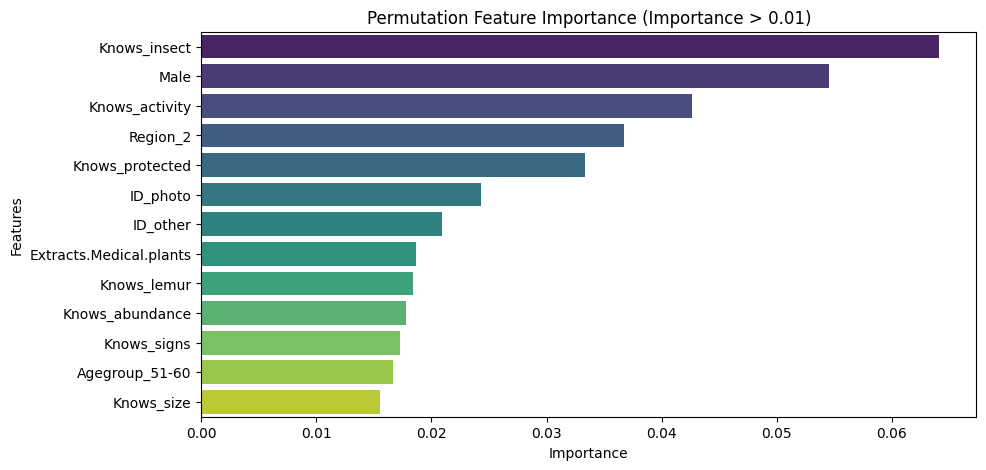

In [55]:
perm_importance = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=Seed)
features = X_test.columns
importances = perm_importance.importances_mean

# Sort features by importance
sorted_indices = np.argsort(importances)[::-1]
# Select only features with importance greater than 0
sorted_features = [features[i] for i in sorted_indices if importances[i] > 0.01]
sorted_importances = [importances[i] for i in sorted_indices if importances[i] > 0.01]

# Plot using Seaborn
plt.figure(figsize=(10, 5))
sns.barplot(x=sorted_importances, y=sorted_features, palette='viridis')
plt.title('Permutation Feature Importance (Importance > 0.01)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

The figure presents the permutation feature importance for a Random Forest classifier, which evaluates the impact of each feature on the model's performance by measuring the decrease in accuracy when feature values are randomly shuffled. "Diet.Insects," "Male," and "Other.lemurs" are identified as the most important features, contributing significantly to the predictive accuracy of the model. In contrast, features such as "Agegroup_51-60" and "Lemur.knowledge" exhibit lower importance, indicating a smaller influence on the model's predictions.

### SHAP Explainer for Random Forest Model

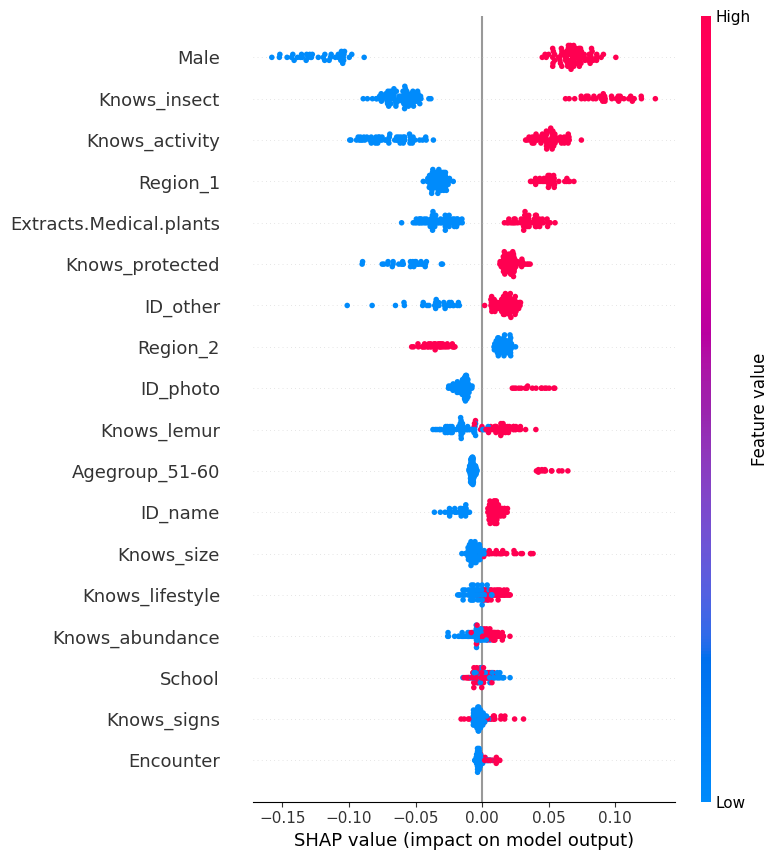

In [57]:
rf.fit(X_train, y_train) 
explainer = shap.TreeExplainer(rf)
# SHAP values for the test set
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(30, 20))
shap.summary_plot(shap_values[1], X_test)  #SHAP values for Class 1

The figure illustrates the SHAP summary plot, which quantifies the contribution of individual features to the model's predictions. Each feature is ranked by its importance, with "Male," "Diet.Insects," and "Activity.knowledge" having the most significant impact. The SHAP values represent the magnitude and direction of each feature's effect, with positive values indicating an increase in the predicted outcome and negative values indicating a decrease. The color gradient reflects feature values, where red corresponds to higher values and blue to lower values.

In [70]:
chi2_stats = []
p_values = []
features = X_merged_encoded.columns

for feature in features:
    contingency_table = pd.crosstab(X_merged_encoded[feature], y_merged_encoded)
    stat, p, _, _ = chi2_contingency(contingency_table, correction=True)  # Yates' correction
    chi2_stats.append(stat)
    p_values.append(p)

# Chi-square results
chi2_results_df = pd.DataFrame({
    'Feature': features,
    'Chi2_Statistic': chi2_stats,
    'P_Value': p_values
}).sort_values(by='Chi2_Statistic', ascending=False)

# Cramér's V for each pair of categorical variables
effect_sizes = {}
target_var = 'Clove.benefit.score'
columns = X_merged_encoded.columns

for col in columns:
    if col != target_var:
        effect_sizes[col] = cramers_v(X_merged_encoded[col], y_merged_encoded)

# Cramér's V results
cramers_v_df = pd.DataFrame(list(effect_sizes.items()), columns=['Feature', 'CramersV_Effect_Size'])

# Permutation Feature Importance (PFI)
perm_importance = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=Seed)
features = X_test.columns
importances = perm_importance.importances_mean

# PFI results
pfi_results_df = pd.DataFrame({
    'Feature': features,
    'PFI_Importance': importances
}).sort_values(by='PFI_Importance', ascending=False)

# Combine PFI, Cramér's V, and Chi-square results
all_results_df = pfi_results_df.merge(chi2_results_df, on='Feature', how='left')  # Merge with Chi-square results
all_results_df = all_results_df.merge(cramers_v_df, on='Feature', how='left')    # Merge with Cramér's V results

doc = Document()
doc.add_heading('All Results', level=1)

# Add a table to the Word document
table = doc.add_table(rows=1, cols=len(all_results_df.columns))
table.style = 'Table Grid'

# Add column headers
for i, column_name in enumerate(all_results_df.columns):
    table.cell(0, i).text = column_name

# Add data rows
for _, row in all_results_df.iterrows():
    row_cells = table.add_row().cells
    for i, (value, col_name) in enumerate(zip(row, all_results_df.columns)):
        if isinstance(value, (int, float)):
            if "P_Value" in col_name:  # Special handling for P-values
                if value < 1e-6:  # Use scientific notation for very small values
                    row_cells[i].text = f"{value:.2e}"
                else:
                    row_cells[i].text = f"{value:.6f}"  # Full precision up to 6 decimal places
            else:
                row_cells[i].text = f"{value:.2f}"  # Two decimal places for other numerical values
        else:
            row_cells[i].text = str(value)

# Save the document
file_path = "All_Results.docx"
doc.save(file_path)

print(f"Results saved to {file_path}")

Results saved to All_Results.docx
